In [8]:
import numpy as np


def read_lta_time_wavelength(filename):
    time_values = []
    wavelength_values = []

    in_measurement_data = False
    header_seen = False

    with open(filename, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()

            if not line:
                continue

            # Start reading after this section
            if line == "[Measurement data]":
                in_measurement_data = True
                continue

            if not in_measurement_data:
                continue

            # Skip metadata line, e.g. "26  0  1"
            if not header_seen:
                if line.startswith("Time"):
                    print("test-time")
                    header_seen = True
                continue

            # Stop if another section begins
            if line.startswith("["):
                break

            parts = line.split()

            # Need at least Time and Signal 1 wavelength
            if len(parts) >= 2:
                try:
                    time_values.append(float(parts[0]))
                    wavelength_values.append(float(parts[1]))
                except ValueError:
                    pass

    Time = np.array(time_values)
    Wavelength = np.array(wavelength_values)
    Frequency = 299792458 / (Wavelength * 1e-9)
    print("time", Time[1])
    print("wave", Wavelength[1])
    print(Frequency[1], "hz")
    return Time, Wavelength, Frequency

Time, Wavelenght, Frequency = read_lta_time_wavelength("unlocked30min.lta")


test-time
time 27.1542
wave 663.57334
451784964718443.9 hz


451784964718443.9 hz


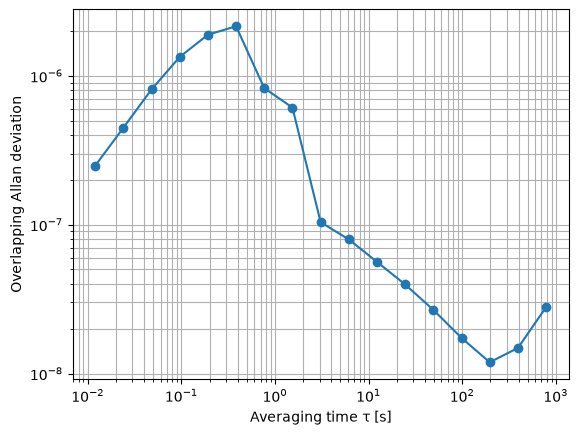

In [24]:
import numpy as np
import allantools
import matplotlib.pyplot as plt

print(Frequency[1], "hz")
# Convert absolute optical frequency to fractional frequency
freq_mean = np.mean(Frequency)
frac_freq = (Frequency - freq_mean) / freq_mean

# Sampling interval from your Time array, assuming Time is in ms
dt = np.mean(np.diff(Time)) * 1e-3  # seconds
rate = 1 / dt                       # Hz
taus, adev, adev_err, ns = allantools.oadev(
    frac_freq,
    rate=rate,
    data_type="freq",
    taus="octave"
)

plt.loglog(taus, adev, marker="o")
plt.xlabel("Averaging time τ [s]")
plt.ylabel("Overlapping Allan deviation")
plt.grid(True, which="both")
plt.show()

In [14]:
dt_ms = np.diff(Time)
print(dt_ms)
print(np.mean(dt_ms))
print(np.std(dt_ms))
print(np.min(dt_ms), np.max(dt_ms))
diffone = Time[2]-Time[1]
print("1-2 t diff", diffone)

[12.957  14.2078 13.0287 ... 11.6808  9.6131 11.1759]
11.990522005860266
33.93932958184874
6.348300000001473 12054.0680999998
1-2 t diff 14.207800000000002


In [19]:
gap_idx = np.where(dt_ms > 100)[0]

print(f"{len(gap_idx)} gaps > 100 ms")

for i in gap_idx[:20]:
    print(i, Time[i], Time[i+1], dt_ms[i])

301 gaps > 100 ms
734 8523.5628 8737.8695 214.306700000001
735 8737.8695 8966.2419 228.3724000000002
4346 39630.6474 40031.1332 400.4857999999949
4374 40360.5142 40765.2395 404.7253000000055
4809 44592.7578 44769.7281 176.97030000000086
4810 44769.7281 44987.512 217.78390000000218
10129 90424.4852 90590.1928 165.70760000000882
10130 90590.1928 90812.1065 221.91369999999006
18742 190086.1285 190450.5649 364.43640000000596
18745 190478.682 190657.0013 178.31930000000284
18746 190657.0013 190842.8107 185.80939999999828
18750 190877.5583 191226.3193 348.7609999999986
21910 227242.7071 227585.3838 342.6767000000109
31703 340603.0358 341015.7687 412.7329000000027
31712 341194.0754 341462.122 268.0466000000015
31713 341462.122 341695.6234 233.5014000000083
32039 345540.8963 345932.5642 391.6679000000004
47824 527248.5006 527590.6059 342.1052999999374
57803 641659.5811 641850.2831 190.70200000004843
57804 641850.2831 642066.5853 216.30220000003465
